<a href="https://colab.research.google.com/github/cesarzepeda17/rush_final_project/blob/main/GB885_Fianl_Project_Zepda_C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RUSH

## Understand the Problem
RUSH, a globally renowned sportswear and footwear brand known for its innovative designs and performance-oriented products.

The VP of US Sales has tasked with analyzing sales data for trends and insights that will help company leadership understand the market and identify opportunities for growth.
2021? In 2020?



In [ ]:
# Import libraries
import pandas as pd
import numpy as np

## Load Data
Load from the different file locations in our google colab to read the csv file and store them in variables.

In [ ]:
import pandas as pd
import numpy as np

# Load to variables
df_table_products = pd.read_csv('/content/sample_data/TABLE_PRODUCTS_885.csv' ,sep='|')
df_table_retailer = pd.read_csv('/content/sample_data/TABLE_RETAILER_885.csv')
df_table_sales = pd.read_csv('/content/sample_data/TABLE_SALES_885.csv')

In [ ]:
# Preview products table
df_table_products.head()

,PRODUCT_ID,PRODUCT_NAME
0,20,Men's Street Footwear
1,30,Men's Athletic Footwear
2,120,Women's Street Footwear
3,130,Women's Athletic Footwear
4,40,Men's Apparel


In [ ]:
# products table info
df_table_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   PRODUCT_ID    6 non-null      int64 
 1   PRODUCT_NAME  6 non-null      object
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes


In [ ]:
# Preview retailer table
df_table_retailer.head()

,RETAILER_ID,RETAILER,REGION,STATE,CITY
0,A00MOHCO,Amazon,Midwest,Ohio,Columbus
1,A00NMAPO,Amazon,Northeast,Maine,Portland
2,A00NMABO,Amazon,Northeast,Massachusetts,Boston
3,A00NNEMA,Amazon,Northeast,New Hampshire,Manchester
4,A00NVEBU,Amazon,Northeast,Vermont,Burlington


In [ ]:
# Retailer info table
df_table_retailer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   RETAILER_ID  110 non-null    object
 1   RETAILER     110 non-null    object
 2   REGION       110 non-null    object
 3   STATE        110 non-null    object
 4   CITY         110 non-null    object
dtypes: object(5)
memory usage: 4.4+ KB


In [ ]:
# Preview sales table
df_table_sales.head(10)

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
0,1,A00MOHCO,1/1/2020,1,1,2020,20,50.0,1200,0.5,In-store
1,7,A00MOHCO,1/7/2020,1,7,2020,20,50.0,1250,0.5,In-store
2,13,A00MOHCO,1/25/2020,1,25,2020,20,50.0,1220,0.5,Outlet
3,19,A00MOHCO,1/31/2020,1,31,2020,20,50.0,1200,0.5,Outlet
4,25,A00MOHCO,2/6/2020,2,6,2020,20,60.0,1220,0.5,Outlet
5,31,A00MOHCO,3/4/2020,3,4,2020,20,60.0,1250,0.5,Outlet
6,37,A00MOHCO,3/10/2020,3,10,2020,20,60.0,1275,0.5,Outlet
7,43,A00MOHCO,3/16/2020,3,16,2020,20,60.0,1250,0.5,Outlet
8,49,A00MOHCO,4/19/2020,4,19,2020,20,60.0,1200,0.5,Outlet
9,57,A00MOHCO,4/27/2020,4,27,2020,20,65.0,1150,0.5,Outlet


In [ ]:
# Sales table table structure
df_table_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDER_ID          9648 non-null   int64  
 1   RETAILER_ID       9648 non-null   object 
 2   INVOICE_DATE      9648 non-null   object 
 3   MONTH             9648 non-null   int64  
 4   DAY               9648 non-null   int64  
 5   YEAR              9648 non-null   int64  
 6   PRODUCT_ID        9648 non-null   int64  
 7   PRICE_PER_UNIT    9646 non-null   float64
 8   UNITS_SOLD        9648 non-null   object 
 9   OPERATING_MARGIN  9648 non-null   float64
 10  SALES_METHOD      9648 non-null   object 
dtypes: float64(2), int64(5), object(4)
memory usage: 829.3+ KB


In [ ]:
# Merge tables into one table "rush_sales_dt"
rush_sales_dt = pd.merge(df_table_sales, df_table_retailer, on='RETAILER_ID', how='left')
rush_sales_dt = pd.merge(rush_sales_dt, df_table_products, on='PRODUCT_ID', how='left')
rush_sales_dt.head(10)

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,RETAILER,REGION,STATE,CITY,PRODUCT_NAME
0,1,A00MOHCO,1/1/2020,1,1,2020,20,50.0,1200,0.5,In-store,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
1,7,A00MOHCO,1/7/2020,1,7,2020,20,50.0,1250,0.5,In-store,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
2,13,A00MOHCO,1/25/2020,1,25,2020,20,50.0,1220,0.5,Outlet,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
3,19,A00MOHCO,1/31/2020,1,31,2020,20,50.0,1200,0.5,Outlet,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
4,25,A00MOHCO,2/6/2020,2,6,2020,20,60.0,1220,0.5,Outlet,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
5,31,A00MOHCO,3/4/2020,3,4,2020,20,60.0,1250,0.5,Outlet,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
6,37,A00MOHCO,3/10/2020,3,10,2020,20,60.0,1275,0.5,Outlet,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
7,43,A00MOHCO,3/16/2020,3,16,2020,20,60.0,1250,0.5,Outlet,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
8,49,A00MOHCO,4/19/2020,4,19,2020,20,60.0,1200,0.5,Outlet,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
9,57,A00MOHCO,4/27/2020,4,27,2020,20,65.0,1150,0.5,Outlet,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear


# Inspect Data
Data inspection (or initial data exploration) is the process of reviewing a dataset's structure, completeness, and value distribution to understand what it contains and identify potential data quality issues before analysis.

In [ ]:
# Info for merged table
rush_sales_dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10271 entries, 0 to 10270
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDER_ID          10271 non-null  int64  
 1   RETAILER_ID       10271 non-null  object 
 2   INVOICE_DATE      10271 non-null  object 
 3   MONTH             10271 non-null  int64  
 4   DAY               10271 non-null  int64  
 5   YEAR              10271 non-null  int64  
 6   PRODUCT_ID        10271 non-null  int64  
 7   PRICE_PER_UNIT    10269 non-null  float64
 8   UNITS_SOLD        10271 non-null  object 
 9   OPERATING_MARGIN  10271 non-null  float64
 10  SALES_METHOD      10271 non-null  object 
 11  RETAILER          10270 non-null  object 
 12  REGION            10270 non-null  object 
 13  STATE             10270 non-null  object 
 14  CITY              10270 non-null  object 
 15  PRODUCT_NAME      10271 non-null  object 
dtypes: float64(2), int64(5), object(9)
memor

In [ ]:
# Convert INVOICE_DATE, MONTH, DAY, YEAR to date format
rush_sales_dt['INVOICE_DATE'] = pd.to_datetime(rush_sales_dt['INVOICE_DATE'])
rush_sales_dt['MONTH'] = pd.to_datetime(rush_sales_dt['MONTH'], format='%m').dt.month
rush_sales_dt['DAY'] = pd.to_datetime(rush_sales_dt['DAY'], format='%d').dt.day
rush_sales_dt['YEAR'] = pd.to_datetime(rush_sales_dt['YEAR'], format='%Y').dt.year
rush_sales_dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10271 entries, 0 to 10270
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ORDER_ID          10271 non-null  int64         
 1   RETAILER_ID       10271 non-null  object        
 2   INVOICE_DATE      10271 non-null  datetime64[ns]
 3   MONTH             10271 non-null  int32         
 4   DAY               10271 non-null  int32         
 5   YEAR              10271 non-null  int32         
 6   PRODUCT_ID        10271 non-null  int64         
 7   PRICE_PER_UNIT    10269 non-null  float64       
 8   UNITS_SOLD        10271 non-null  object        
 9   OPERATING_MARGIN  10271 non-null  float64       
 10  SALES_METHOD      10271 non-null  object        
 11  RETAILER          10270 non-null  object        
 12  REGION            10270 non-null  object        
 13  STATE             10270 non-null  object        
 14  CITY              1027

In [ ]:
# Sum total null for each column
rush_sales_dt.isnull().sum()

,0
ORDER_ID,0
RETAILER_ID,0
INVOICE_DATE,0
MONTH,0
DAY,0
YEAR,0
PRODUCT_ID,0
PRICE_PER_UNIT,2
UNITS_SOLD,0
OPERATING_MARGIN,0


In [ ]:
# Non-traditional Categorical data

# list of categorical variables in dataframe
cat_var = list(rush_sales_dt.select_dtypes(include=['object']).columns)

# view unique values for each vategorical variables
for column in cat_var:
  print(column)
  print(rush_sales_dt[column].unique())


RETAILER_ID
['A00MOHCO' 'A00NMAPO' 'A00NMABO' 'A00NNEMA' 'A00NVEBU' 'A00SALBI'
 'A00SKELO' 'A00SNOCH' 'A00WALAN' 'F00SLONE' 'F00SGEAT' 'F00SVIRI'
 'F00WALAN' 'F00WARPH' 'F00WHAHO' 'F00MNEOM' 'F00WIDBO' 'F00WWYCH'
 'F00MILCH' 'F00MIODE' 'F00MKAWI' 'F00MMIDE' 'F00MMIMI' 'F00MMIST'
 'F00MNOFA' 'F00MSOSI' 'F00NCOHA' 'F00NDEWI' 'F00NMABA' 'F00NNEMA'
 'F00SFLMI' 'F00NNENE' 'F00NPEPH' 'F00SKELO' 'F00NRHPR' 'F00SSOCH'
 'F00NWECH' 'F00SMIJA' 'F00STEKN' 'F00STEDA' 'F00WCALO' 'F00WWASE'
 'K00WARPH' 'K00WNEAL' 'K00NDEWI' 'K00NNENE' 'K00NNEAL' 'K00WWYCH'
 'K00MMIMI' 'K00MMOBI' 'K00WCALO' 'K00WCASA' 'K00MKAWI' 'K00SOKOK'
 'S00MILCH' 'S00SFLOR' 'S00SGEAT' 'S00MMOBI' 'S00SVIRI' 'S00MNEOM'
 'S00WHAHO' 'S00WNEAL' 'S00MMIDE' 'S00MNOFA' 'S00MSOSI' 'S00NCOHA'
 'S00NMABA' 'S00NNENE' 'S00NMABO' 'S00NRHPR' 'S00SMIJA' 'S00SFLMI'
 'S00SNOCH' 'S00SSOCH' 'S00SALBI' 'S00STEKN' 'S00STEDA' 'S00STEHO'
 'S00WIDBO' 'W00SFLOR' 'W00WHAHO' 'W00NNENE' 'W00SMIJA' 'W00SARLI'
 'W00STEHO' 'W00NMAPO' 'W00NPEPH' 'W00SLONE' 'W00W

In [ ]:
# Non-traditional null values: numerical data
rush_sales_dt.describe()

,ORDER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,OPERATING_MARGIN
count,10271.000000,10271,10271.000000,10271.000000,10271.000000,10271.000000,10269.000000,10271.000000
mean,4970.630903,2021-05-13 12:00:54.678220288,6.456333,14.620290,2020.873235,80.001947,54.575324,0.426380
min,1.000000,2020-01-01 00:00:00,1.000000,1.000000,2020.000000,20.000000,7.000000,0.100000
25%,2568.500000,2021-02-18 00:00:00,3.000000,9.000000,2021.000000,30.000000,35.000000,0.350000
50%,5136.000000,2021-06-05 00:00:00,6.000000,14.000000,2021.000000,120.000000,45.000000,0.420000
75%,7236.000000,2021-09-17 00:00:00,9.000000,20.000000,2021.000000,130.000000,55.000000,0.500000
max,9648.000000,2021-12-31 00:00:00,12.000000,31.000000,2021.000000,140.000000,99999.000000,0.800000
std,2770.737186,NaN,3.461826,7.301233,0.332725,50.671441,986.473924,0.096018


# Cleaning Data
Data cleaning (or data cleansing) is the process of fixing or removing incorrect, corrupted, incorrectly formatted, duplicate, or incomplete data within a dataset.

In [ ]:
# Remove unwanted columns from the table
remove_features = ['RETAILER_ID', 'PRODUCT_ID']

# drop the features
rush_sales_dt = rush_sales_dt.drop(remove_features, axis=1)

In [ ]:
# Convert UNITS_SOLD to numeric
rush_sales_dt['UNITS_SOLD'] = pd.to_numeric(rush_sales_dt['UNITS_SOLD'], errors='coerce')
rush_sales_dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10271 entries, 0 to 10270
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ORDER_ID          10271 non-null  int64         
 1   INVOICE_DATE      10271 non-null  datetime64[ns]
 2   MONTH             10271 non-null  int32         
 3   DAY               10271 non-null  int32         
 4   YEAR              10271 non-null  int32         
 5   PRICE_PER_UNIT    10269 non-null  float64       
 6   UNITS_SOLD        10269 non-null  float64       
 7   OPERATING_MARGIN  10271 non-null  float64       
 8   SALES_METHOD      10271 non-null  object        
 9   RETAILER          10270 non-null  object        
 10  REGION            10270 non-null  object        
 11  STATE             10270 non-null  object        
 12  CITY              10270 non-null  object        
 13  PRODUCT_NAME      10271 non-null  object        
dtypes: datetime64[ns](1), 

In [ ]:
# Inspect the row for the numerical value for the max price per unit of 999999
rush_sales_dt[rush_sales_dt['PRICE_PER_UNIT']==99999].head()

,ORDER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,RETAILER,REGION,STATE,CITY,PRODUCT_NAME
423,2536,2021-05-23,5,23,2021,99999.0,520.0,0.4,Online,Foot Locker,Northeast,New Hampshire,Manchester,Men's Street Footwear


In [ ]:
# Inspect the row for numerical value 0 in UNIT_SOLD
rush_sales_dt[rush_sales_dt['UNITS_SOLD']==0].head()

,ORDER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,RETAILER,REGION,STATE,CITY,PRODUCT_NAME
7016,1020,2021-06-05,6,5,2021,35.0,0.0,0.40,Outlet,Foot Locker,Southeast,Virginia,Richmond,Women's Athletic Footwear
7017,1026,2021-06-11,6,11,2021,30.0,0.0,0.40,Outlet,Foot Locker,Southeast,Virginia,Richmond,Women's Athletic Footwear
7663,4908,2021-06-05,6,5,2021,33.0,0.0,0.55,Online,Sports Direct,Midwest,Michigan,Detroit,Women's Athletic Footwear
7664,4914,2021-06-11,6,11,2021,27.0,0.0,0.53,Online,Sports Direct,Midwest,Michigan,Detroit,Women's Athletic Footwear


In [ ]:
# remove unit sold 0 rows
rush_sales_dt = rush_sales_dt[rush_sales_dt['UNITS_SOLD'] != 0]

In [ ]:
# Grouped mode imputation (more precise for retail datasets)
rush_sales_dt["PRICE_PER_UNIT"] = rush_sales_dt["PRICE_PER_UNIT"].replace(99999.0, np.nan)
rush_sales_dt["PRICE_PER_UNIT"] = rush_sales_dt.groupby("PRODUCT_NAME")["PRICE_PER_UNIT"].transform(
    lambda x: x.fillna(x.mode()[0])
)

In [ ]:
rush_sales_dt.isnull().sum()

,0
ORDER_ID,0
INVOICE_DATE,0
MONTH,0
DAY,0
YEAR,0
PRICE_PER_UNIT,0
UNITS_SOLD,2
OPERATING_MARGIN,0
SALES_METHOD,0
RETAILER,1


In [ ]:
rush_sales_dt[rush_sales_dt['UNITS_SOLD'].isna()].head()

,ORDER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,RETAILER,REGION,STATE,CITY,PRODUCT_NAME
1021,6064,2021-05-27,5,27,2021,51.0,NaN,0.45,Online,Sports Direct,South,Alabama,Birmingham,Men's Street Footwear
1527,8626,2021-12-10,12,10,2021,29.0,NaN,0.46,Outlet,West Gear,Midwest,Iowa,Des Moines,Men's Street Footwear


In [ ]:
# Remove null values from table
rush_sales_dt = rush_sales_dt.dropna()
rush_sales_dt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10264 entries, 0 to 10270
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ORDER_ID          10264 non-null  int64         
 1   INVOICE_DATE      10264 non-null  datetime64[ns]
 2   MONTH             10264 non-null  int32         
 3   DAY               10264 non-null  int32         
 4   YEAR              10264 non-null  int32         
 5   PRICE_PER_UNIT    10264 non-null  float64       
 6   UNITS_SOLD        10264 non-null  float64       
 7   OPERATING_MARGIN  10264 non-null  float64       
 8   SALES_METHOD      10264 non-null  object        
 9   RETAILER          10264 non-null  object        
 10  REGION            10264 non-null  object        
 11  STATE             10264 non-null  object        
 12  CITY              10264 non-null  object        
 13  PRODUCT_NAME      10264 non-null  object        
dtypes: datetime64[ns](1), float

In [ ]:
# Show duplicate values
rush_sales_dt[rush_sales_dt.duplicated()]

,ORDER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,RETAILER,REGION,STATE,CITY,PRODUCT_NAME


# Prepare for Analysis
In this stage, the cleaned and processed data is transformed and structured into a format suitable for answering specific business questions and generating insights.


*   What product category (product) had the highest sales (in dollars) in 2021? How much did it sell?
*   What state had the highest sales (in dollars) of women's products in 2021? How much was it?
*   What state had the highest sales (in dollars) of men's products in 2021? How much was it?
*   What retailer purchased the most units in

In [ ]:
# Add a column for SALES
rush_sales_dt['SALES'] = rush_sales_dt['UNITS_SOLD'] * rush_sales_dt['PRICE_PER_UNIT']
rush_sales_dt.head()

,ORDER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,RETAILER,REGION,STATE,CITY,PRODUCT_NAME,SALES
0,1,2020-01-01,1,1,2020,50.0,1200.0,0.5,In-store,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear,60000.0
1,7,2020-01-07,1,7,2020,50.0,1250.0,0.5,In-store,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear,62500.0
2,13,2020-01-25,1,25,2020,50.0,1220.0,0.5,Outlet,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear,61000.0
3,19,2020-01-31,1,31,2020,50.0,1200.0,0.5,Outlet,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear,60000.0
4,25,2020-02-06,2,6,2020,60.0,1220.0,0.5,Outlet,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear,73200.0


# Analysis
In this stage, the prepared data is explored using various analytical techniques and visualizations to uncover trends, patterns, and relationships, ultimately leading to actionable insights and answers to the business questions.

In [ ]:
# descriptive statistics
rush_descriptive = rush_sales_dt.select_dtypes(include=np.number)
rush_descriptive.describe()

,ORDER_ID,MONTH,DAY,YEAR,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES
count,10264.000000,10264.000000,10264.000000,10264.000000,10264.000000,10264.000000,10264.000000,10264.000000
mean,4970.588854,6.456060,14.621298,2020.873149,44.848012,246.729345,0.426358,11923.870031
std,2770.637600,3.462529,7.300679,0.332822,14.790179,211.876117,0.096036,12524.619929
min,1.000000,1.000000,1.000000,2020.000000,7.000000,6.000000,0.100000,160.000000
25%,2568.750000,3.000000,9.000000,2021.000000,35.000000,100.000000,0.350000,3750.000000
50%,5136.500000,6.000000,14.000000,2021.000000,45.000000,173.000000,0.420000,7308.000000
75%,7236.000000,9.000000,20.000000,2021.000000,55.000000,325.000000,0.500000,15000.000000
max,9648.000000,12.000000,31.000000,2021.000000,110.000000,1275.000000,0.800000,82500.000000


In [ ]:
# Correlation for the numeric values
rush_descriptive.corr()

,ORDER_ID,MONTH,DAY,YEAR,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES
ORDER_ID,1.000000,-0.001769,-0.031926,0.206518,-0.316620,-0.680531,0.329525,-0.642354
MONTH,-0.001769,1.000000,-0.008994,0.038622,0.269418,-0.009903,0.034681,0.064758
DAY,-0.031926,-0.008994,1.000000,-0.065166,0.086825,-0.026685,-0.022320,0.000629
YEAR,0.206518,0.038622,-0.065166,1.000000,-0.148613,-0.194976,0.089802,-0.203407
PRICE_PER_UNIT,-0.316620,0.269418,0.086825,-0.148613,1.000000,0.274001,-0.139297,0.538867
UNITS_SOLD,-0.680531,-0.009903,-0.026685,-0.194976,0.274001,1.000000,-0.319313,0.921334
OPERATING_MARGIN,0.329525,0.034681,-0.022320,0.089802,-0.139297,-0.319313,1.000000,-0.314006
SALES,-0.642354,0.064758,0.000629,-0.203407,0.538867,0.921334,-0.314006,1.000000


## What product category (product) had the highest sales (in dollars) in 2021? How much did it sell?

In [ ]:
# Filter data for 2021
sales_2021 = rush_sales_dt[rush_sales_dt['YEAR'] == 2021]

# Group by PRODUCT_NAME and sum SALES
product_sales_2021 = sales_2021.groupby('PRODUCT_NAME')['SALES'].sum().reset_index()

# Find the product with the highest sales
highest_sales_product = product_sales_2021.loc[product_sales_2021['SALES'].idxmax()]

print(f"The product category with the highest sales in 2021 was '{highest_sales_product['PRODUCT_NAME']}' with total sales of ${highest_sales_product['SALES']:.2f}.")

The product category with the highest sales in 2021 was 'Men's Street Footwear' with total sales of $23283356.00.


## What state had the highest sales (in dollars) of women's products in 2021? How much was it?

In [ ]:
# Filter data for 2021 and women's products
women_products_2021 = sales_2021[sales_2021['PRODUCT_NAME'].str.contains("Women's", case=False)]

# Group by STATE and sum SALES
state_sales_women_2021 = women_products_2021.groupby('STATE')['SALES'].sum().reset_index()

# Find the state with the highest sales for women's products
highest_sales_state_women = state_sales_women_2021.loc[state_sales_women_2021['SALES'].idxmax()]

print(f"The state with the highest sales of women's products in 2021 was '{highest_sales_state_women['STATE']}' with total sales of ${highest_sales_state_women['SALES']:.2f}.")

The state with the highest sales of women's products in 2021 was 'Maine' with total sales of $2176301.00.


## What state had the highest sales (in dollars) of men's products in 2021? How much was it?

In [ ]:
# Filter data for 2021 and men's products
men_products_2021 = sales_2021[sales_2021['PRODUCT_NAME'].str.contains("Men's", case=False)]

# Group by STATE and sum SALES
state_sales_men_2021 = men_products_2021.groupby('STATE')['SALES'].sum().reset_index()

# Find the state with the highest sales for men's products
highest_sales_state_men = state_sales_men_2021.loc[state_sales_men_2021['SALES'].idxmax()]

print(f"The state with the highest sales of men's products in 2021 was '{highest_sales_state_men['STATE']}' with total sales of ${highest_sales_state_men['SALES']:.2f}.")

The state with the highest sales of men's products in 2021 was 'Maine' with total sales of $4393491.00.


## What retailer purchased the most units in 2021? In 2020?

In [ ]:
# Filter data for 2021
sales_2021_retailer = rush_sales_dt[rush_sales_dt['YEAR'] == 2021]

# Group by RETAILER and sum UNITS_SOLD for 2021
retailer_units_2021 = sales_2021_retailer.groupby('RETAILER')['UNITS_SOLD'].sum().reset_index()

# Find the retailer with the most units sold in 2021
highest_units_retailer_2021 = retailer_units_2021.loc[retailer_units_2021['UNITS_SOLD'].idxmax()]

print(f"In 2021, the retailer that purchased the most units was '{highest_units_retailer_2021['RETAILER']}' with a total of {highest_units_retailer_2021['UNITS_SOLD']:.0f} units.")

# Filter data for 2020
sales_2020_retailer = rush_sales_dt[rush_sales_dt['YEAR'] == 2020]

# Group by RETAILER and sum UNITS_SOLD for 2020
retailer_units_2020 = sales_2020_retailer.groupby('RETAILER')['UNITS_SOLD'].sum().reset_index()

# Find the retailer with the most units sold in 2020
highest_units_retailer_2020 = retailer_units_2020.loc[retailer_units_2020['UNITS_SOLD'].idxmax()]

print(f"In 2020, the retailer that purchased the most units was '{highest_units_retailer_2020['RETAILER']}' with a total of {highest_units_retailer_2020['UNITS_SOLD']:.0f} units.")

In 2021, the retailer that purchased the most units was 'Foot Locker' with a total of 1097410 units.
In 2020, the retailer that purchased the most units was 'Amazon' with a total of 317930 units.


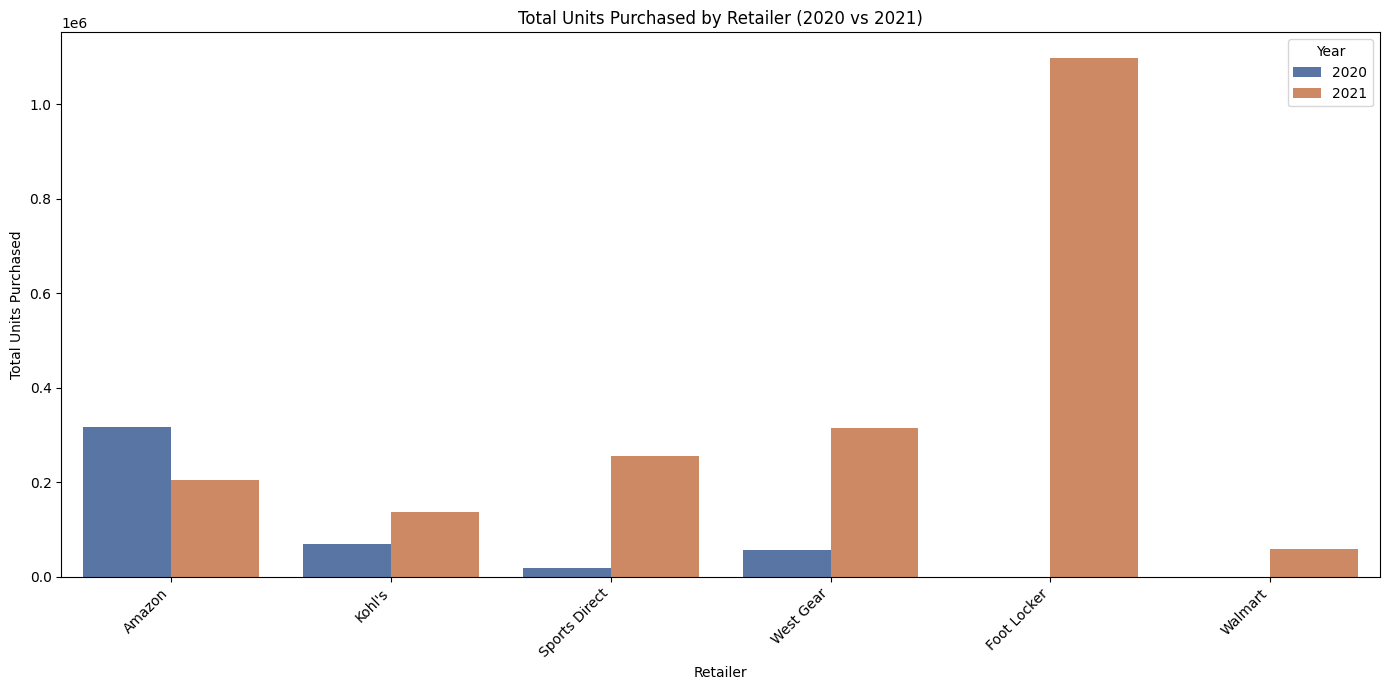

In [ ]:
# Add a 'YEAR' column to each DataFrame for proper grouping
retailer_units_2020['YEAR'] = 2020
retailer_units_2021['YEAR'] = 2021

# Combine the two DataFrames
combined_retailer_units = pd.concat([retailer_units_2020, retailer_units_2021])

# Create the bar chart
plt.figure(figsize=(14, 7))
sns.barplot(x='RETAILER', y='UNITS_SOLD', hue='YEAR', data=combined_retailer_units, palette='deep')
plt.title('Total Units Purchased by Retailer (2020 vs 2021)')
plt.xlabel('Retailer')
plt.ylabel('Total Units Purchased')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

In [ ]:
# Install the 'us' library to get state abbreviations
%pip install us -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 2.1 MB/s eta 0:00:00


## Visual Analysis

In [ ]:
# import visualization libraries
import us
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns


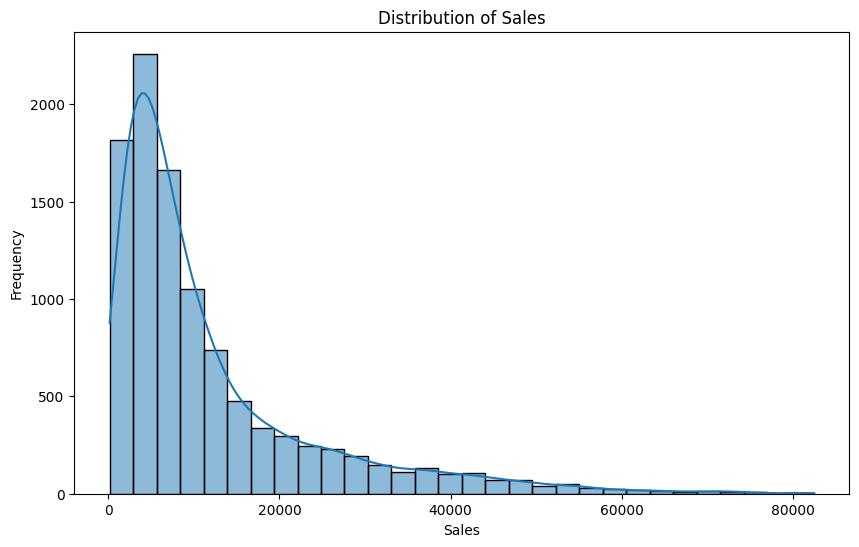

In [ ]:
# Create a histogram of sales using seaborn
plt.figure(figsize=(10, 6))
sns.histplot(rush_sales_dt['SALES'], bins=30, kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Create a dictionary to map full state names to abbreviations
state_to_abbrev = {state.name: state.abbr for state in us.states.STATES}

# Add a 'STATE_ABBREV' column to the DataFrame
# Handle potential missing states by filling with an empty string
state_sales_women_2021['STATE_ABBREV'] = state_sales_women_2021['STATE'].map(state_to_abbrev).fillna('')

# Ensure the 'STATE_ABBREV' column is explicitly of string type
state_sales_women_2021['STATE_ABBREV'] = state_sales_women_2021['STATE_ABBREV'].astype(str)

# Get the min and max sales for the color range
min_sales = state_sales_women_2021['SALES'].min()
max_sales = state_sales_women_2021['SALES'].max()

# Create the choropleth map using state abbreviations
fig = px.choropleth(state_sales_women_2021,
                    locations='STATE_ABBREV',
                    locationmode='USA-states',
                    color='SALES',
                    scope='usa',
                    color_continuous_scale="Viridis",
                    range_color=[min_sales, max_sales],
                    title='2021 Women\'s Product Sales by State')

# Display the map
fig.show()